Econml with lag features

C1 : Temp is variable Himidity is constant

In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('/Users/ameypatil/Desktop/Tata Power/data/final.csv')

In [3]:
# Drop useless columns
df = df.drop(columns=['_id_x', '_id_y'])

# Datetime handling
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')
df.set_index('datetime', inplace=True)

# Time features
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek

# Lag features (important even for causal ML)
df['lag_24'] = df['wdLoad'].shift(24)
df['lag_168'] = df['wdLoad'].shift(168)

# Drop NaN
df = df.dropna()

In [4]:
Y = df['wdLoad'].values        # outcome
T = df['temp'].values          # treatment

X = df[['hour', 'dayofweek', 'rh', 'lag_24', 'lag_168']].values

In [5]:
from econml.dml import CausalForestDML

model = CausalForestDML(
    n_estimators=100,
    min_samples_leaf=10,
    random_state=42
)

model.fit(Y, T, X=X)

In [6]:
effects = model.effect(X)

print(effects[:10])

[-1.50948207 -1.51457871 -1.92583495 -1.73566297 -1.8590433  -3.13107582
 -2.74536329 -1.6870404  -0.69036099 -0.81896608]


In [7]:
ate = model.ate(X)
print("ATE:", ate)

ATE: 1.0019618096480878


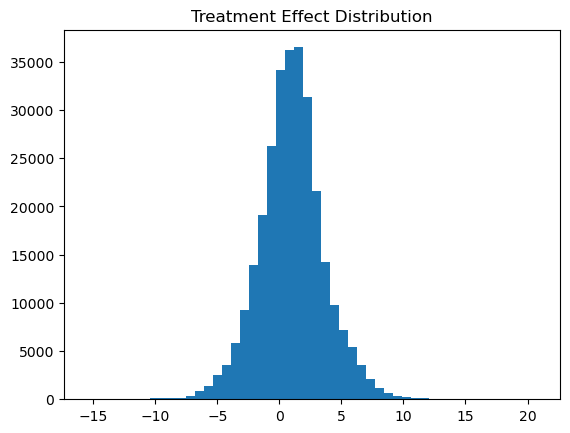

In [8]:
import matplotlib.pyplot as plt

plt.hist(effects, bins=50)
plt.title("Treatment Effect Distribution")
plt.show()

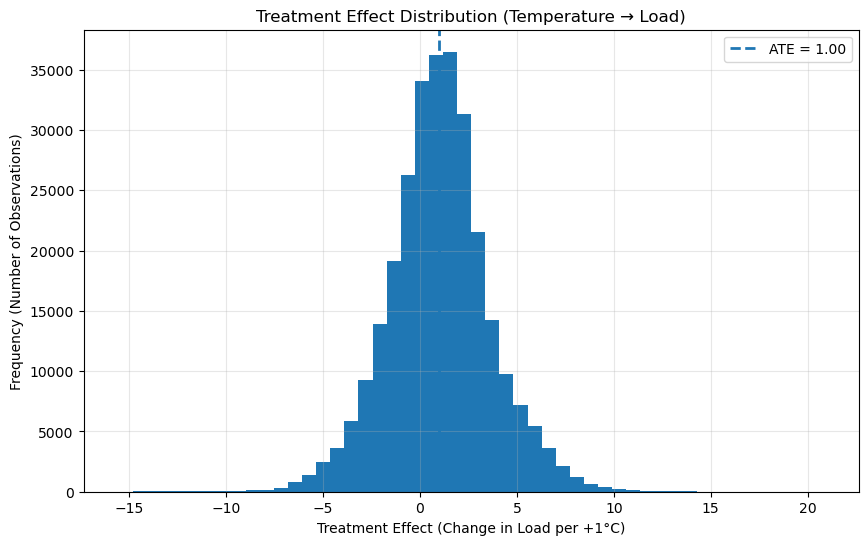

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate ATE
ate = np.mean(effects)

plt.figure(figsize=(10,6))

# Histogram
plt.hist(effects, bins=50)

# ATE line
plt.axvline(ate, linestyle='--', linewidth=2, label=f'ATE = {ate:.2f}')

# Labels
plt.title("Treatment Effect Distribution (Temperature → Load)")
plt.xlabel("Treatment Effect (Change in Load per +1°C)")
plt.ylabel("Frequency (Number of Observations)")

# Legend
plt.legend()

# Grid for clarity
plt.grid(alpha=0.3)

plt.show()

In [10]:
import pandas as pd

df_effect = pd.DataFrame(X, columns=['hour','dayofweek','rh','lag_24','lag_168'])
df_effect['effect'] = effects

print(df_effect.groupby('hour')['effect'].mean())

hour
0.0    -0.476895
1.0    -0.447242
2.0     0.163150
3.0     0.481309
4.0     0.466691
5.0     0.760281
6.0     1.787414
7.0     2.470238
8.0     2.851323
9.0     2.541552
10.0    1.785203
11.0    0.935412
12.0   -0.794006
13.0   -1.670270
14.0   -1.292593
15.0   -1.009835
16.0   -0.299878
17.0    1.801390
18.0    3.065533
19.0    3.470930
20.0    2.982948
21.0    2.235861
22.0    1.682665
23.0    0.557217
Name: effect, dtype: float64


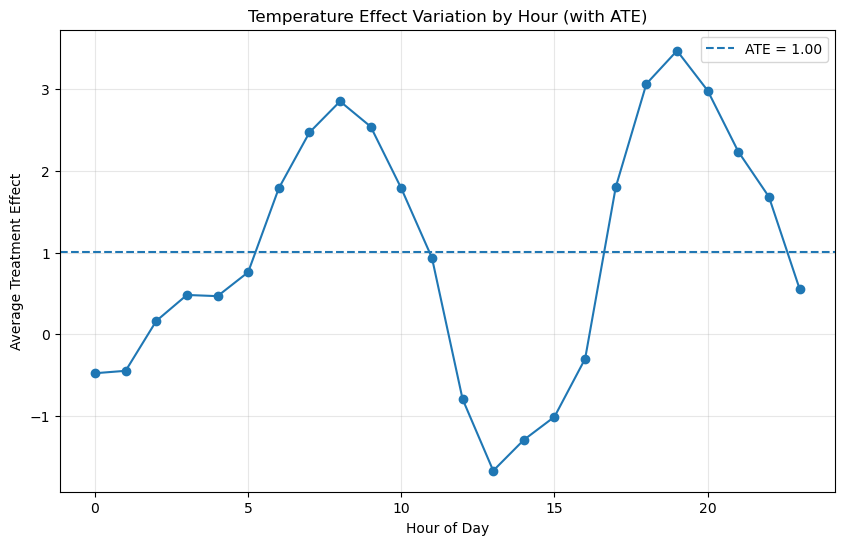

In [21]:

ate = np.mean(effects)
effect_by_hour = df_effect.groupby('hour')['effect'].mean()
plt.figure(figsize=(10,6))

plt.plot(effect_by_hour.index, effect_by_hour.values, marker='o')
plt.axhline(ate, linestyle='--', label=f'ATE = {ate:.2f}')

plt.xlabel("Hour of Day")
plt.ylabel("Average Treatment Effect")
plt.title("Temperature Effect Variation by Hour (with ATE)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

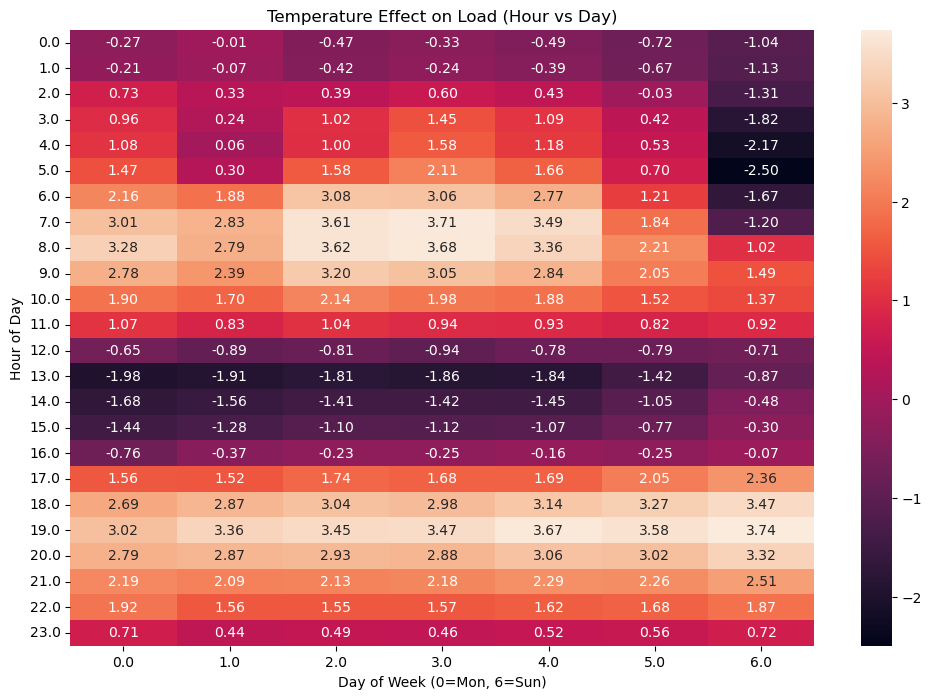

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create dataframe with effects
df_effect = pd.DataFrame(X, columns=['hour','dayofweek','rh','lag_24','lag_168'])
df_effect['effect'] = effects

# Create pivot table
pivot_table = df_effect.pivot_table(
    values='effect',
    index='hour',
    columns='dayofweek'
)

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(pivot_table, annot=True, fmt=".2f")

plt.title("Temperature Effect on Load (Hour vs Day)")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Hour of Day")

plt.show()

C2 : Temp is Constant and Humidity is variable

In [11]:
Y1 = df['wdLoad'].values        # outcome
T1 = df['rh'].values          # treatment

X1 = df[['hour', 'dayofweek', 'temp', 'lag_24', 'lag_168']].values

In [12]:
from econml.dml import CausalForestDML

model1 = CausalForestDML(
    n_estimators=100,
    min_samples_leaf=10,
    random_state=42
)

model1.fit(Y1, T1, X=X1)

In [13]:
effects1 = model1.effect(X)

print(effects1[:10])

[-0.27398826 -0.29333227 -0.32024586 -0.30844963 -0.29293379 -0.2879988
 -0.26188913 -0.25546522 -0.25775592 -0.24984714]


In [14]:
ate1 = model1.ate(X1)
print("ATE:", ate1)

ATE: 0.018584329618791882


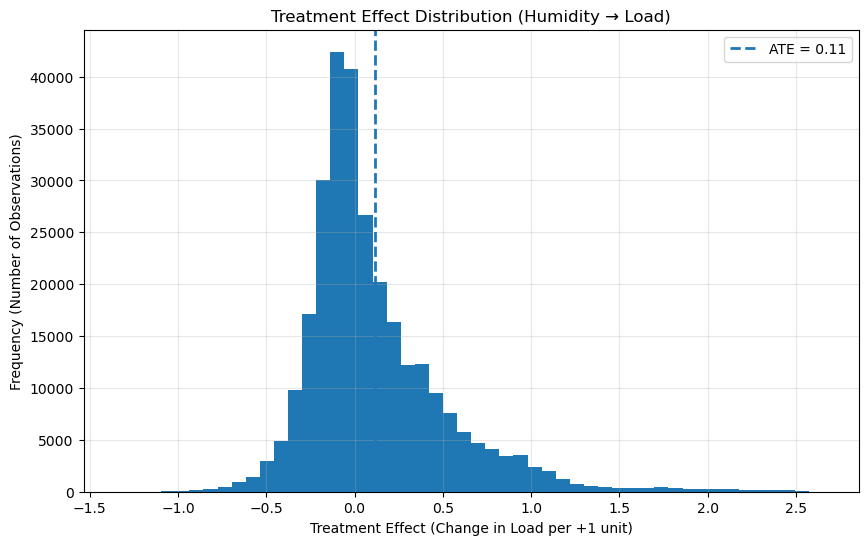

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate ATE
ate1 = np.mean(effects1)

plt.figure(figsize=(10,6))

# Histogram
plt.hist(effects1, bins=50)

# ATE line
plt.axvline(ate1, linestyle='--', linewidth=2, label=f'ATE = {ate1:.2f}')

# Labels
plt.title("Treatment Effect Distribution (Humidity → Load)")
plt.xlabel("Treatment Effect (Change in Load per +1 unit)")
plt.ylabel("Frequency (Number of Observations)")

# Legend
plt.legend()

# Grid for clarity
plt.grid(alpha=0.3)

plt.show()

In [16]:
import pandas as pd

df_effect1 = pd.DataFrame(X1, columns=['hour','dayofweek','temp','lag_24','lag_168'])
df_effect1['effect'] = effects1

print(df_effect1.groupby('hour')['effect'].mean())

hour
0.0     0.107488
1.0     0.112865
2.0     0.107773
3.0     0.095475
4.0     0.048345
5.0     0.074903
6.0     0.229128
7.0     0.360971
8.0     0.520670
9.0     0.656928
10.0    0.364543
11.0   -0.027572
12.0   -0.087585
13.0   -0.101151
14.0   -0.117476
15.0   -0.069340
16.0    0.000673
17.0    0.029403
18.0    0.015519
19.0   -0.084169
20.0   -0.063134
21.0    0.087628
22.0    0.219641
23.0    0.266357
Name: effect, dtype: float64


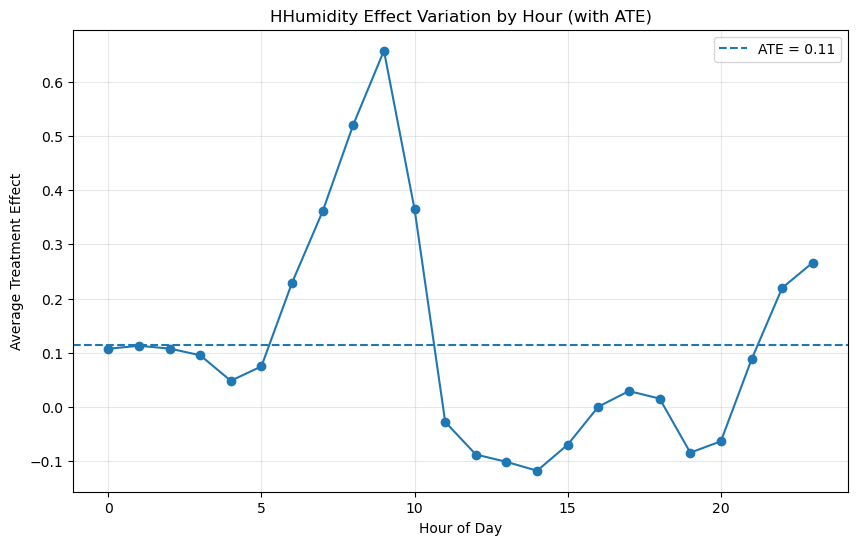

In [20]:
ate1 = np.mean(effects1)
effect_by_hour1 = df_effect1.groupby('hour')['effect'].mean()
plt.figure(figsize=(10,6))

plt.plot(effect_by_hour1.index, effect_by_hour1.values, marker='o')
plt.axhline(ate1, linestyle='--', label=f'ATE = {ate1:.2f}')

plt.xlabel("Hour of Day")
plt.ylabel("Average Treatment Effect")
plt.title("HHumidity Effect Variation by Hour (with ATE)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

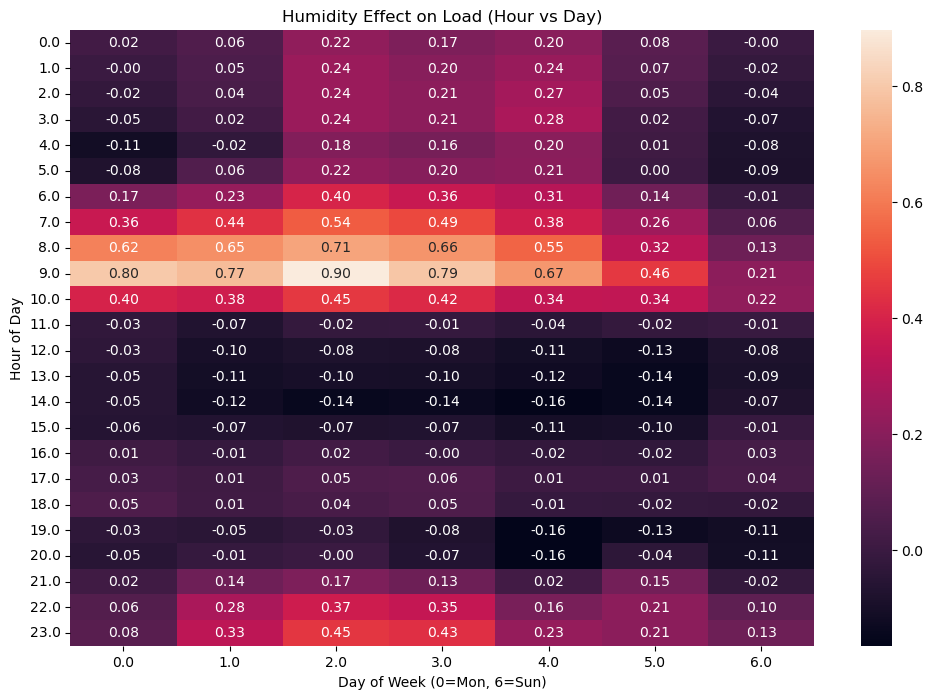

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create dataframe with effects
df_effect1 = pd.DataFrame(X, columns=['hour','dayofweek','temp','lag_24','lag_168'])
df_effect1['effect'] = effects1

# Create pivot table
pivot_table1 = df_effect1.pivot_table(
    values='effect',
    index='hour',
    columns='dayofweek'
)

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(pivot_table1, annot=True, fmt=".2f")

plt.title("Humidity Effect on Load (Hour vs Day)")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Hour of Day")

plt.show()